<h1 style="display: flex; align-items: center; justify-content: space-between;">
	Music Information Retrieval
	<img src="https://www.upf.edu/documents/8071534/8177261/MTG_logo-07.png/c5d8ed89-90cf-7fbb-6116-1ab41706aa85?t=1578480743718"
			alt="MTG logo"
			width="180"
			style="vertical-align: middle; margin-left: 20px;" />
</h1>

> This notebook is part of the **Music Information Retrieval (MIR)** course within the  
[**Sound and Music Computing (SMC)**](https://www.upf.edu/web/smc) programme  
at the **Music Technology Group (MTG), Universitat Pompeu Fabra**.

---

### How to Run the Notebook
You can download the notebook and run it locally on your computer.

Alternatively, to access some GPU time for free, open it directly in **Google Colab**.

---

## Homework 2

**Instructions:**

1. Complete parts 1 through 5, filling in code in the `utils.py` file where indicated **# YOUR CODE HERE** or responses in `this notebook` where marked with **# YOUR RESPONSE HERE** or **# YOUR CODE HERE**.
2. **Document** your code. Add comments explaining what the different parts of your code are doing.
3. If you copy code from external resources (e.g. librosa's examples), include references as comments.
4. When finished, commit and push this completed notebook file along with the `utils.py` file to your GitHub repository corresponding to this homework.
5. **IMPORTANT:** do not modify any of the provided code.

**How to work with the `utils.py` file and Google Colab:**

You can run your code remotely with Google Colab if you add the `utils.py` file to your files' folder (search for the folder icon in the menu on the left). But **CAREFUL**, you should copy any changes you make to `utils.py` in Colab to a local copy. Each time you re-start a session the changes of any file in the files folder are lost.

**Grading:**

- This homework is worth **15 points**.
- Each function you code in `utils.py` is worth 1 point, for a total of 5 points.
- ✏️ Task 1: Compare chroma features (1 points)
- ✏️ Task 2: Discuss the results of conformer vs conformer_decomposed architectures (2 points)
- ✏️ Task 3: Discuss the results of training with a more limited vocabulary (2 points)
- ✏️ Task 4: Identify and discuss errors (2 points)
- ✏️ Task 5: Implement and discuss your extension (3 points)

- Points will be automatically assigned when passing tests, and manually assigned when it comes to your written responses.

**Academic integrity:**

Remember that this homework should be authored by you only. It's ok to discuss with classmates but you have to submit your own original solution.

---

# Automatic Chord Estimation using Deep Learning
___

In this homework we will explore automatic chord estimation (ACE), this is a long-standing task in Music Information Retrieval (MIR) that aims to estimate the sequence of musical chords directly from audio. We will be analysing and using the Isophonics dataset [[1]](#ref1). and the McGill Billboard corpus [[2]](#ref2) for training and validation, and the RWC Pop [[3]](#ref3) and USPop [[4]](#ref4) datasets as test sets. We will be training and evaluating the model proposed by Poltronieri et al. [[5]](#ref5) in the paper *From Discord to Harmony: Decomposed Consonance-Based Training for Improved Audio Chord Estimation*.

### Extra resources
For more information and other practical examples of chord recognition and related MIR techniques, see the FMP (Fundamentals of Music Processing) materials from [Audiolabs Erlangen website](https://www.audiolabs-erlangen.de/resources/MIR/FMP/C5/C5.html).


### Notes on CPU vs GPU environments
The model we examine in this notebook is fairly computationally intensive and we suggest training on a GPU. As a reference benchmark, training for 10 epochs on the free T4 GPU on Google Colab took ~20 mins.

### References

<a id="ref1"></a>
[1] M. Mauch, C. Cannam, M. Davies, S. Dixon, C. Harte, S. Kolozali, D. Tidhar, and M. Sandler, “Omras2 metadata project 2009,” in Proceedings of the 10th International Society for Music Information Retrieval Conference, ISMIR 2009, Kobe International Conference Center, Kobe, Japan, October 26-30, 2009, 2009.

<a id="ref2"></a>
[2] J. A. Burgoyne, J. Wild, and I. Fujinaga, “An expert ground truth set for audio chord recognition and music analysis,” in Proceedings of the 12th International Society for Music Information Retrieval Conference, ISMIR 2011, Miami, Florida, USA, October 24-28, 2011, A. Klapuri and C. Leider, Eds. University of Miami, 2011, pp. 633–638.

<a id="ref3"></a>
[3] M. Goto, H. Hashiguchi, T. Nishimura, and R. Oka, “RWC music database: Popular, classical and jazz music databases,” in ISMIR 2002, 3rd International Conference on Music Information Retrieval, Paris, France, October 13-17, 2002, Proceedings, 2002, pp. 287–288.

<a id="ref4"></a>
[4] J. Jiang, K. Chen, W. Li, and G. Xia, “Largevocabulary chord transcription via chord structure decomposition,” in Proceedings of the 20th International Society for Music Information Retrieval Conference, ISMIR 2019, Delft, The Netherlands, November 4-8, 2019, A. Flexer, G. Peeters, J. Urbano, and A. Volk, Eds., 2019, pp. 644–651.

<a id="ref5"></a>
[5] A. Poltronieri, X. Serra, and M. Rocamora, “From discord to harmony: decomposed consonance-based training for improved audio chord estimation,” in Proc. 26th Int. Soc. Music Inf. Retrieval Conf. (ISMIR), Daejeon, South Korea, 2025. Available: http://hdl.handle.net/10230/71120


## ⚙️ Setup environment
___


### Install packages

In [9]:
!pip install git+https://github.com/andreamust/consonance-ACE.git

  Cloning https://github.com/andreamust/consonance-ACE.git to c:\users\user\appdata\local\temp\pip-req-build-g5rf8zk_
  Resolved https://github.com/andreamust/consonance-ACE.git to commit f34ef4d74bd7345cf17cd0597cb4bbf58adb3e74
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/andreamust/consonance-ACE.git 'C:\Users\User\AppData\Local\Temp\pip-req-build-g5rf8zk_'

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
%pip install torch torchvision torchaudio "numpy<2.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [11]:
# imports
import auxiliary as a
import utils as u

### Login to Weights & Biases

In [12]:
# Login to Weights & Biases for experiment tracking
!pip install wandb
import wandb
wandb.login()


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\User\_netrc.
wandb: Currently logged in as: rafaeleduardo-moncayo01 (rafaeleduardo-moncayo01-universitat-pompeu-fabra) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Part 1: Inspect the data
___

### Load the data

We provide several folders and files for use in this notebook.

- `preprocessed_data` - The preprocessed CQT files (stored as .pt files).
- `jams` - The JAMS reference files (these store the chord annotations).
- `test_audio` - Some sample audio files from the test set. For use only within this homework!
- `chords_vocab.joblib` the label encoder for the chord vocabulary.
- `conformer_decomposed_smooth.ckpt` pre-trained conformer_decomposed model.


If you don't have a GPU, you will want to set up the data in Colab in a way that is easily managed. We suggest you download the preprocessed features and put them in your drive.

Then you can copy this data to the colab session when you need to use it which will be much faster to read when training the model.

For example:

```python
import os
from google.colab import drive

drive.mount('/content/drive') # Mount the drive

# Define source and destination paths
source_path = '/content/drive/MyDrive/path_to_dataset_in_your_drive/MIR_Homework_2_Data.zip'
destination_path = '.'  # Current working directory

# Copy the file using the shell command
!cp "{source_path}" "{destination_path}"

# Unzip the file
!unzip MIR_Homework_2_Data.zip

# Unzip each file
!unzip MIR_Homework_2_Data/preprocessed_data.zip
!unzip MIR_Homework_2_Data/jams.zip
!unzip MIR_Homework_2_Data/test_audio.zip

# Copy chord vocab file and checkpoint file out to root
!cp MIR_Homework_2_Data/chords_vocab.joblib .
!cp MIR_Homework_2_Data/conformer_decomposed_smooth.ckpt .
```

### Analyse major/minor chord distribution

Implement `load_chord_data` and `get_chord_stats` in `utils.py` then run the code below.

In [13]:
JAMS_FOLDER = "MIR_Homework_2_Data\\jams\\jams" # Ensure you set this to the folder where your JAMS files are located
CORPORA = ["MARL-Chords", "Billboard-Chords", "Isophonics"]

df = u.load_chord_data(JAMS_FOLDER)
#print(df)
for each in CORPORA:
	a.print_chord_stats(u.get_chord_stats(df,[each]), title=f"{each} set statistics")

MARL-Chords set statistics
Total chords: 1,322
Unique chords: 165

Billboard-Chords set statistics
Total chords: 5,079
Unique chords: 200

Isophonics set statistics
Total chords: 890
Unique chords: 84



In [14]:
print(df.head())
for each in CORPORA:
	a.print_chord_stats(u.get_chord_stats(df,[each]), title=f"{each} set statistics")

                      file      corpus   chord
0  TRAKIXJ149E332D53F.jams  Isophonics       D
1  TRAKIXJ149E332D53F.jams  Isophonics  A:min7
2  TRAKIXJ149E332D53F.jams  Isophonics       D
3  TRAKIXJ149E332D53F.jams  Isophonics  A:min7
4  TRAKIXJ149E332D53F.jams  Isophonics       D
MARL-Chords set statistics
Total chords: 1,322
Unique chords: 165

Billboard-Chords set statistics
Total chords: 5,079
Unique chords: 200

Isophonics set statistics
Total chords: 890
Unique chords: 84



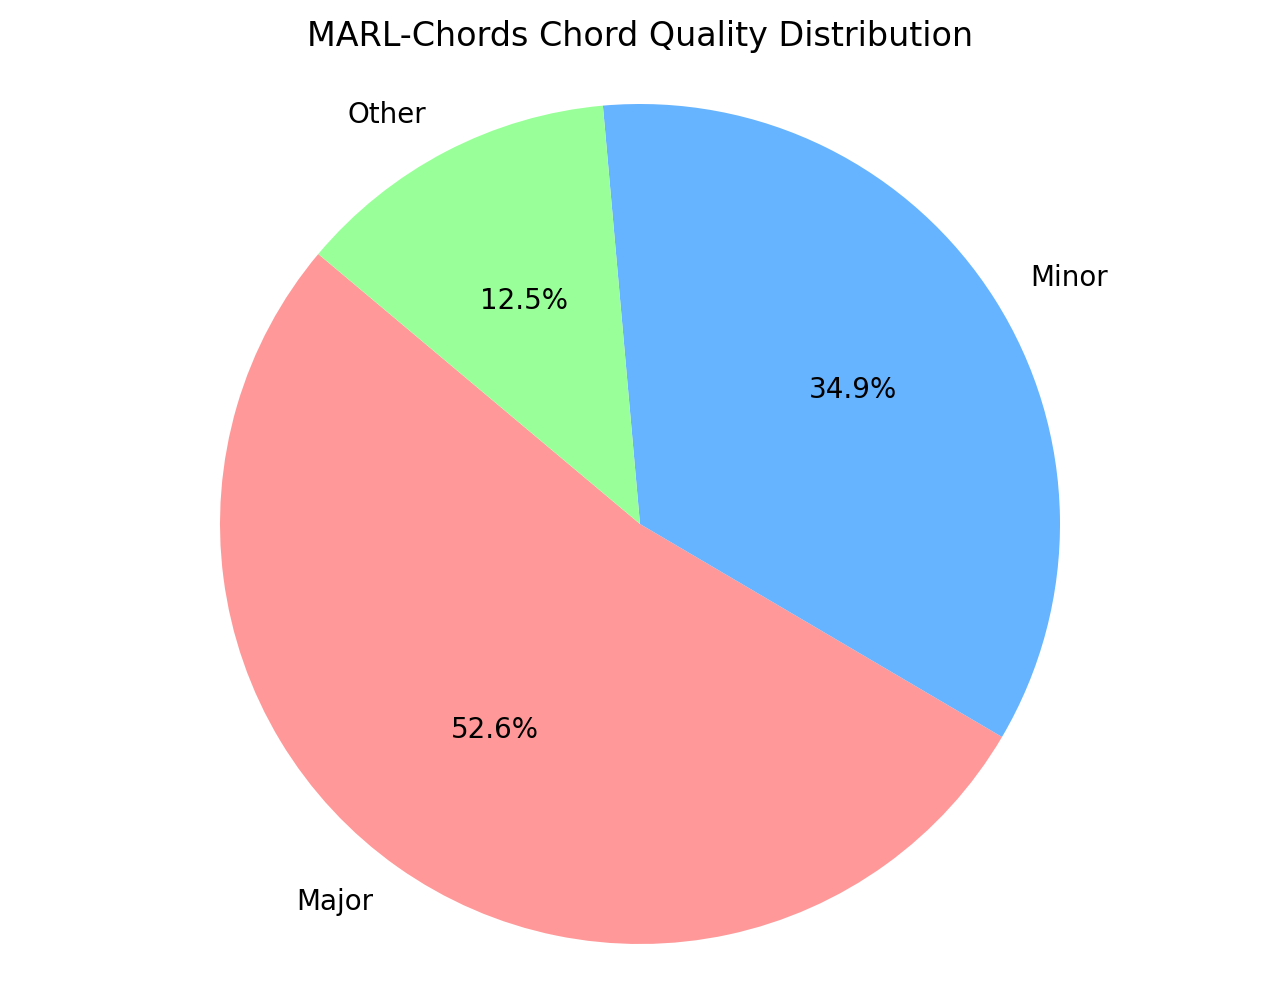

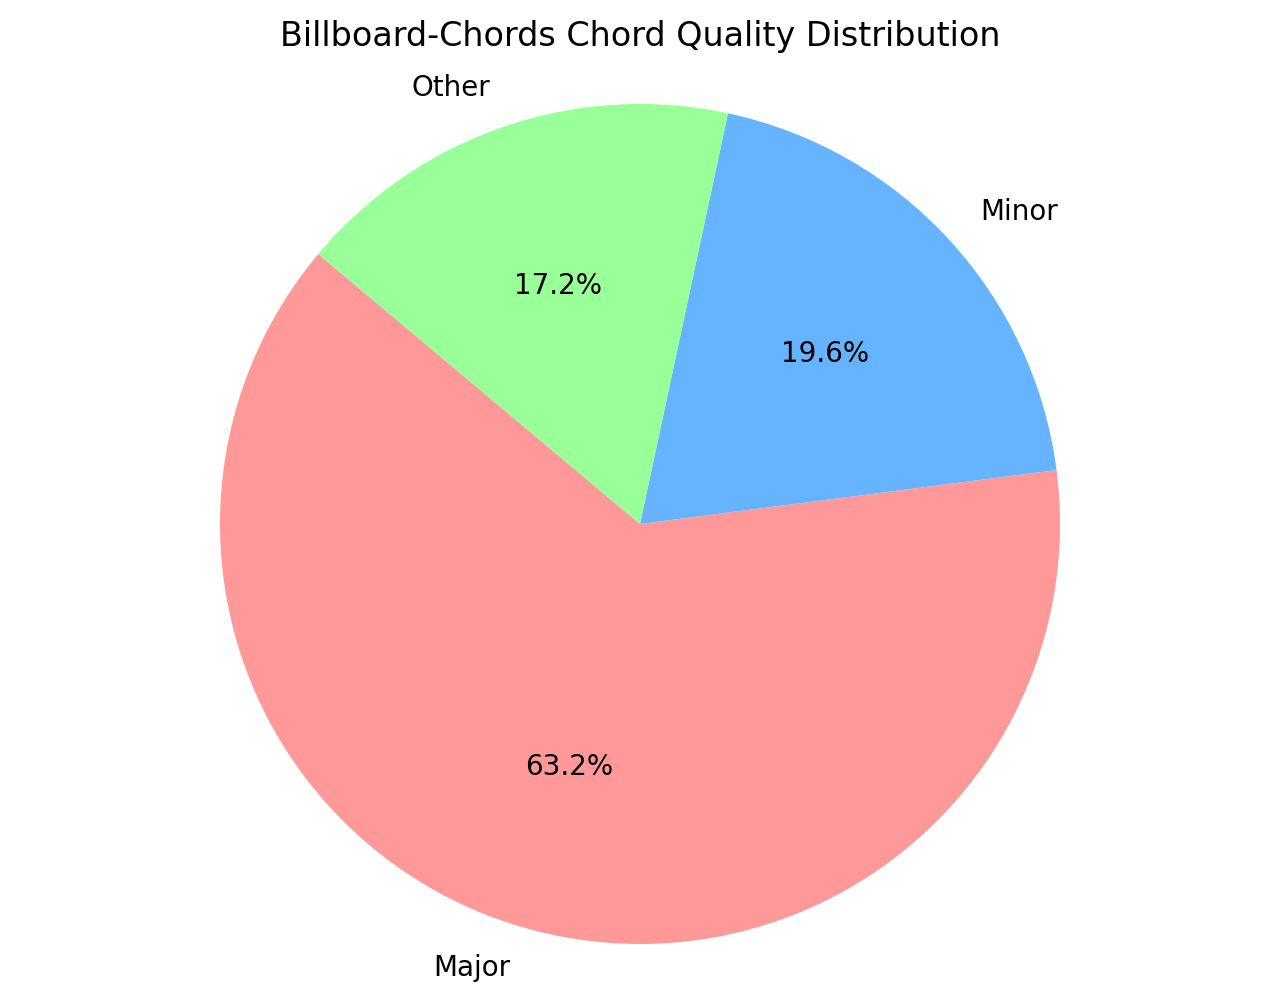

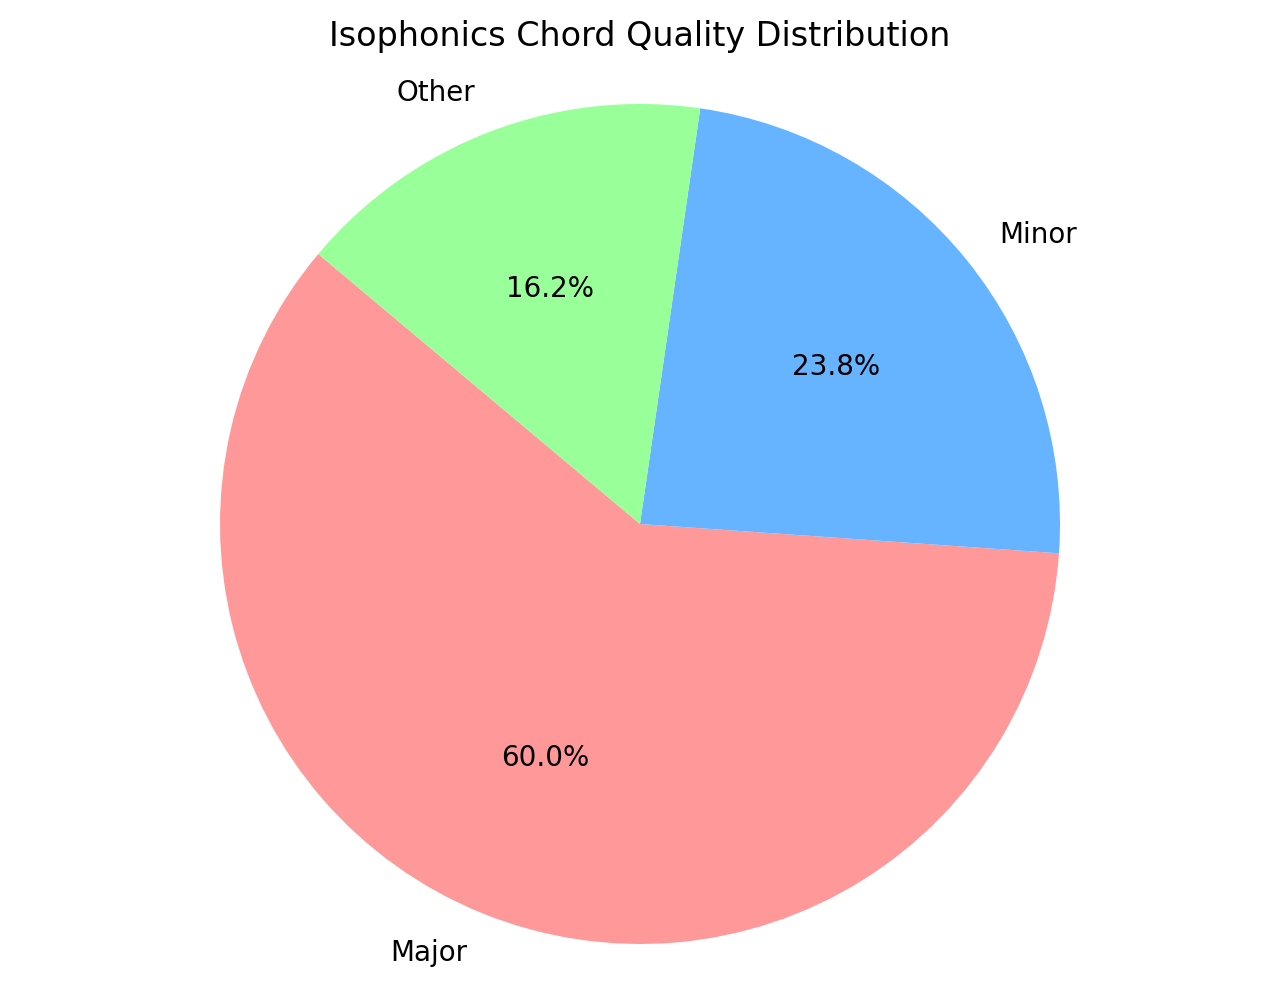

In [15]:
for each in CORPORA:
	a.plot_chord_distribution(u.get_chord_stats(df, [each]), title=f"{each} Chord Quality Distribution")

### Explore different chroma representations

We provide some audio files of the test data. Using librosa you should implement the function `compute_chroma_features` in `utils.py`. Exploring, calculating and plotting different chroma features for one of the `test_audio` files.

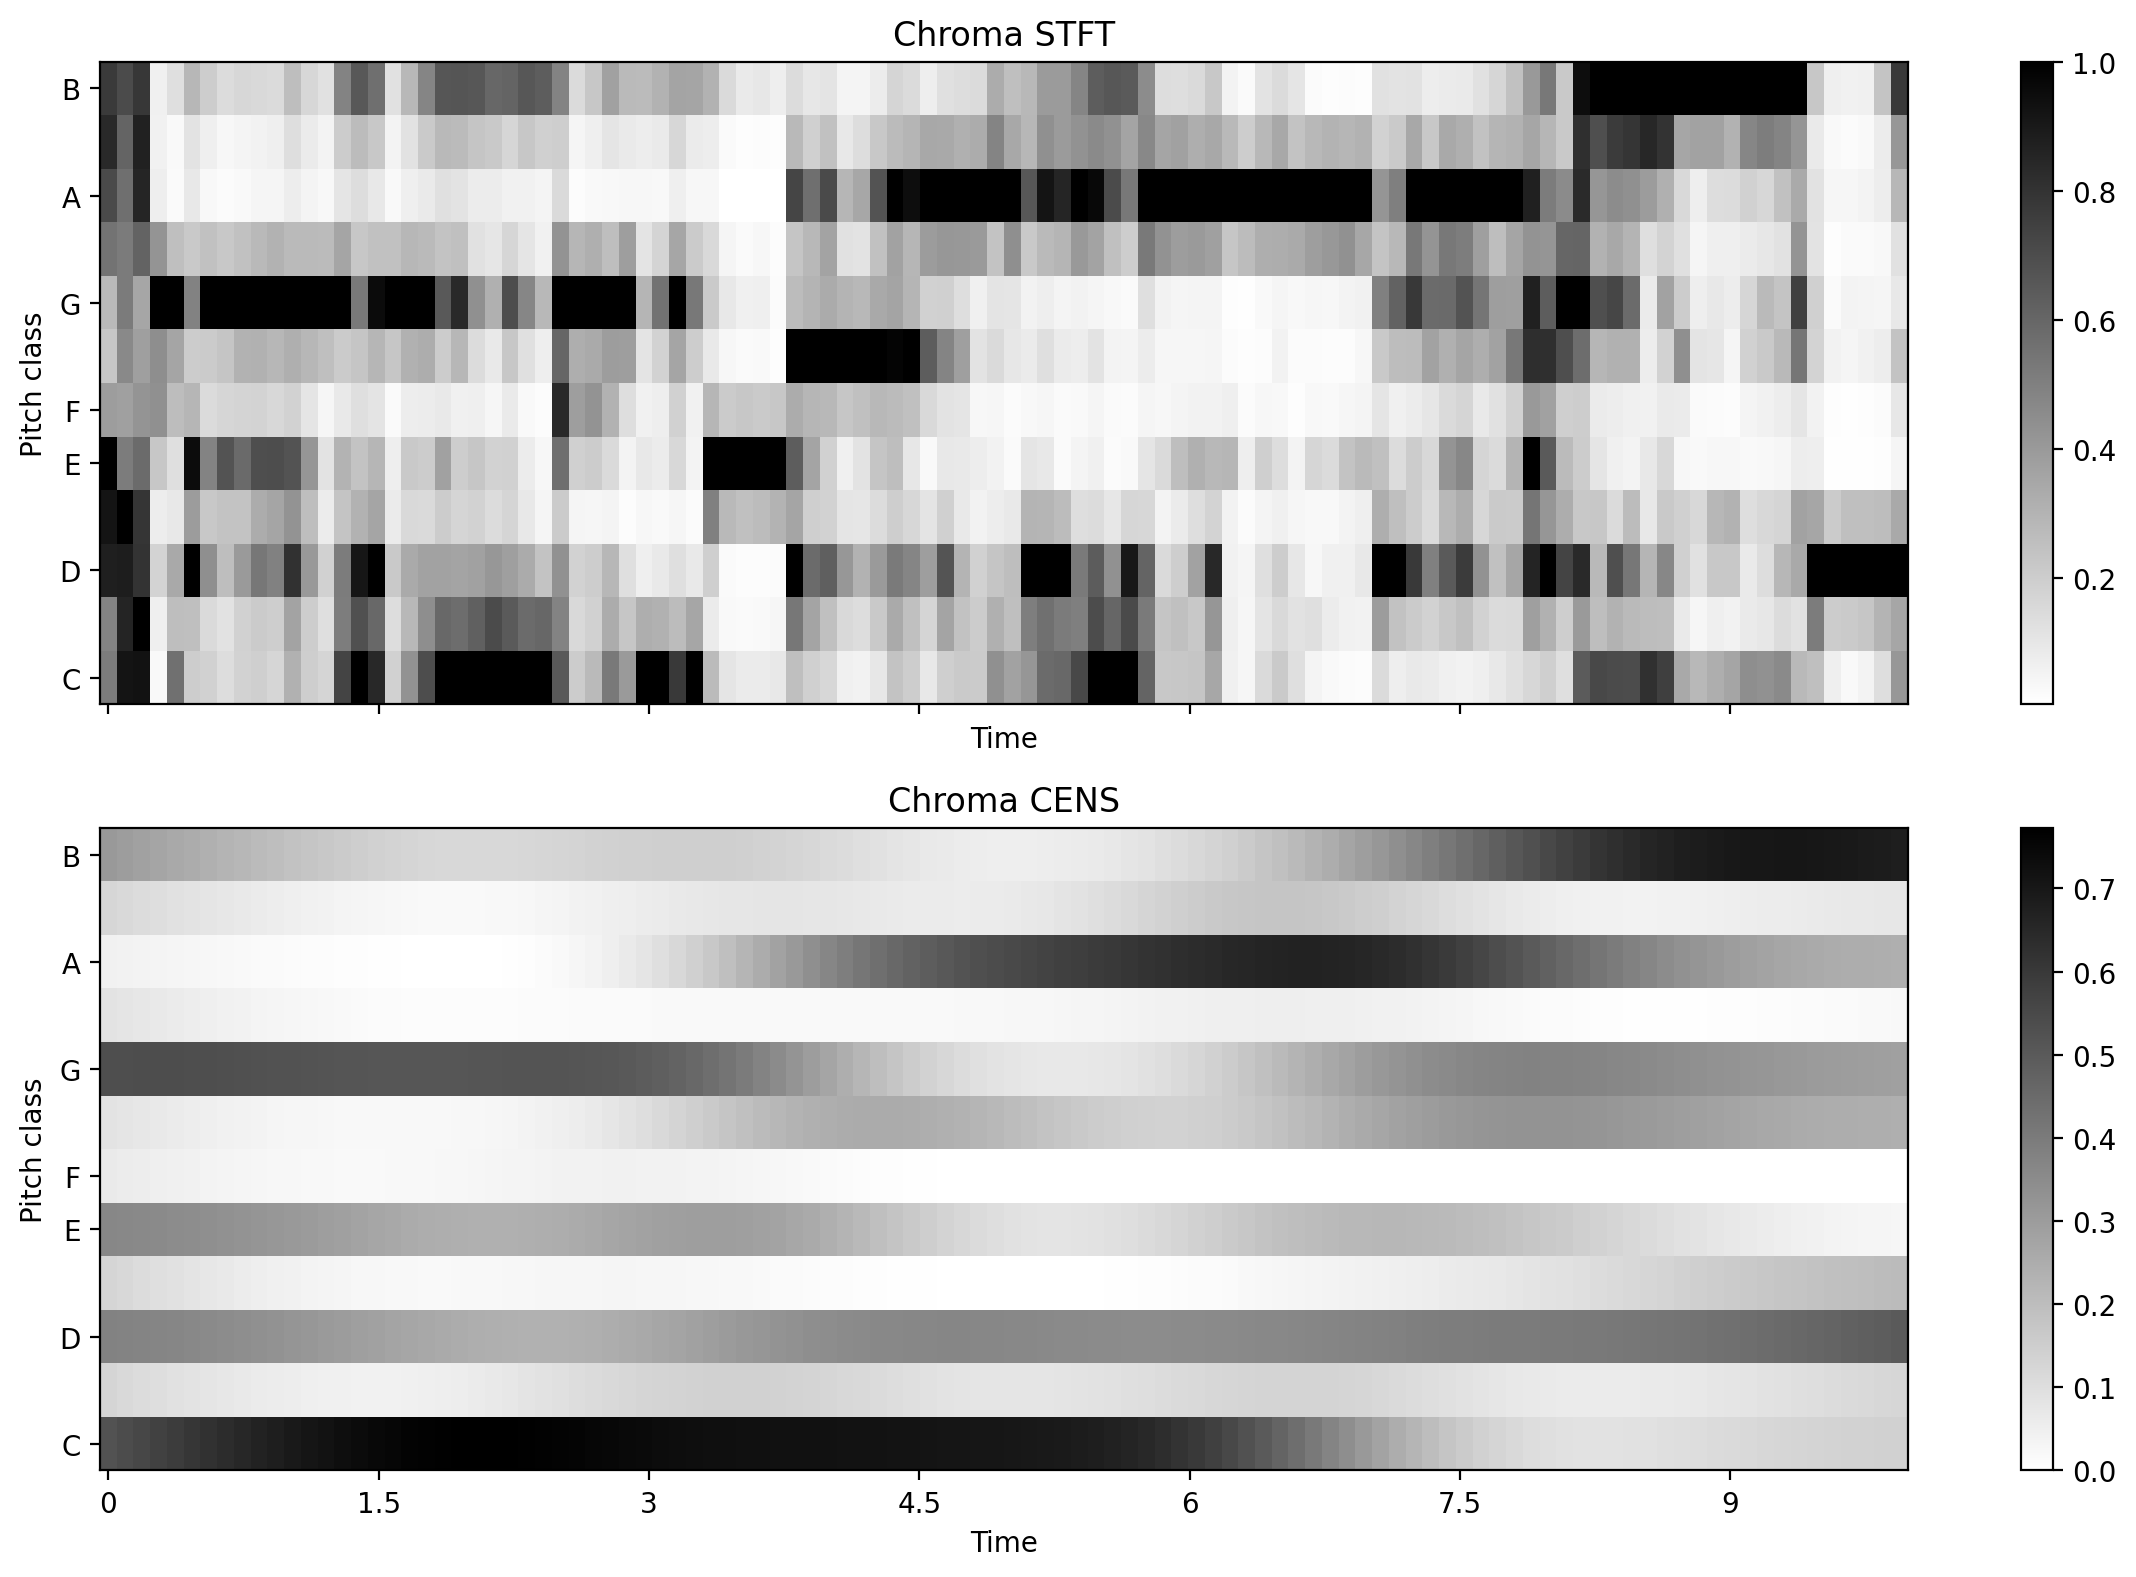

In [16]:
import utils as u
import auxiliary as a

# Hint: You might need to experiment with the parameters for chroma_cens calculations to get a nice plot.
chroma_dict = u.compute_chroma_features("MIR_Homework_2_Data\\test_audio\\test_audio\\TRYNQFC149E3E14844.mp3")

a.plot_chroma_features(chroma_dict)

### ✏️ Task 1: Compare chroma features

After computing and plotting both **STFT chroma** and **CENS chroma** for your audio example, compare the two representations in the context of **automatic chord recognition**. In a short paragraph, discuss the **benefits and drawbacks** of each feature type. Considering aspects such as temporal resolution, robustness to dynamics and noise, and suitability for identifying stable harmonic content.

> YOUR RESPONSE HERE

When comparing STFT and CENS chromagrams, it is evident that CENS effectively clusters chroma energy, facilitating a clearer identification of the underlying chords. In the selected example, energy is predominantly concentrated between C and G as sustained notes; while energy distribution is less uniform for the remaining notes of the primary chord (E, D, and B), they remain distinguishable. Therefore the representation remains robust against intensity variations. 
However, the primary trade-off is a reduction in temporal resolution; this smoothing effect may result in the loss of fine-grained information, such as rapid arpeggios or transient notes between chord changes.

### Visualise the pre-processed data


The pre-processed data consists of:

- Constant-Q Transform (CQT) spectrograms stored as .pt tensors, representing the audio in time–frequency form.

- Frame-level chord labels aligned with each CQT frame, saved inside the accompanying jams object.

- Chord vocabularies (e.g., full or simplified labels) encoded using a LabelEncoder for consistent numerical representation.

From [[5]](#ref5):
> "As a first step, the audio is first resampled to a sampling rate of 22050 Hz, and a hop size of 2048 is applied. Then, the Constant-Q Transform (CQT) features are calculated on 6 octaves starting from C1, with 24 bins per octave, resulting in a total of 144 bins."

Use the functions below to visualise some of the provided pre-processed data.

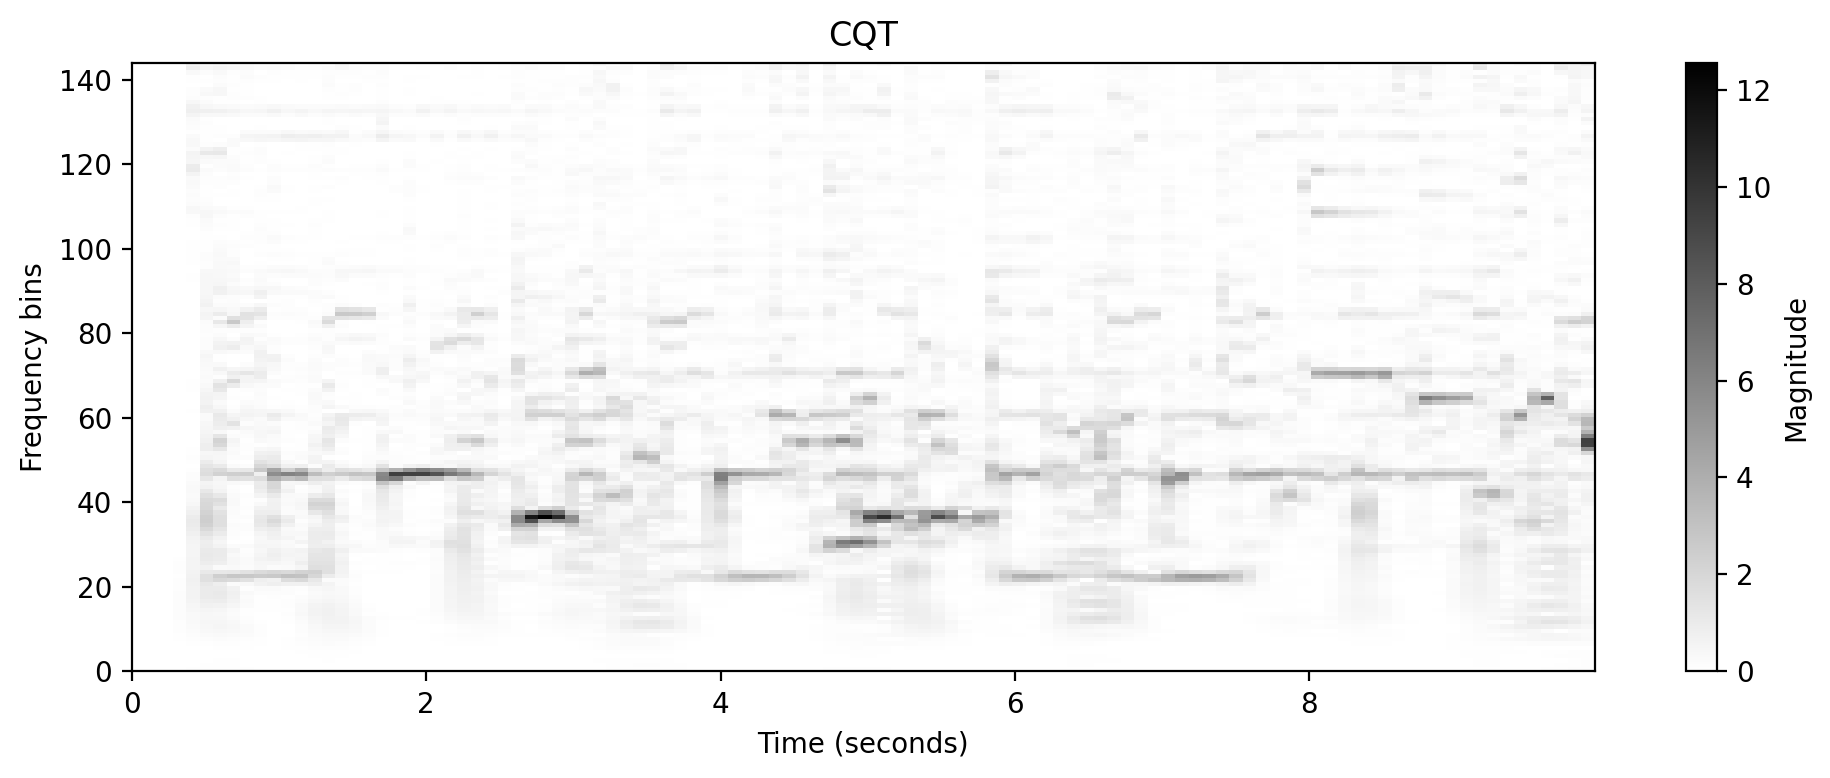

In [17]:
# Visualise a CQT file from the provided pre-processed dataset (these are .pt files)
a.load_and_plot_cqt("MIR_Homework_2_Data\\preprocessed_data\\preprocessed_data\\Billboard_TRBGZPI149E312C871_t0000_p+2.pt")

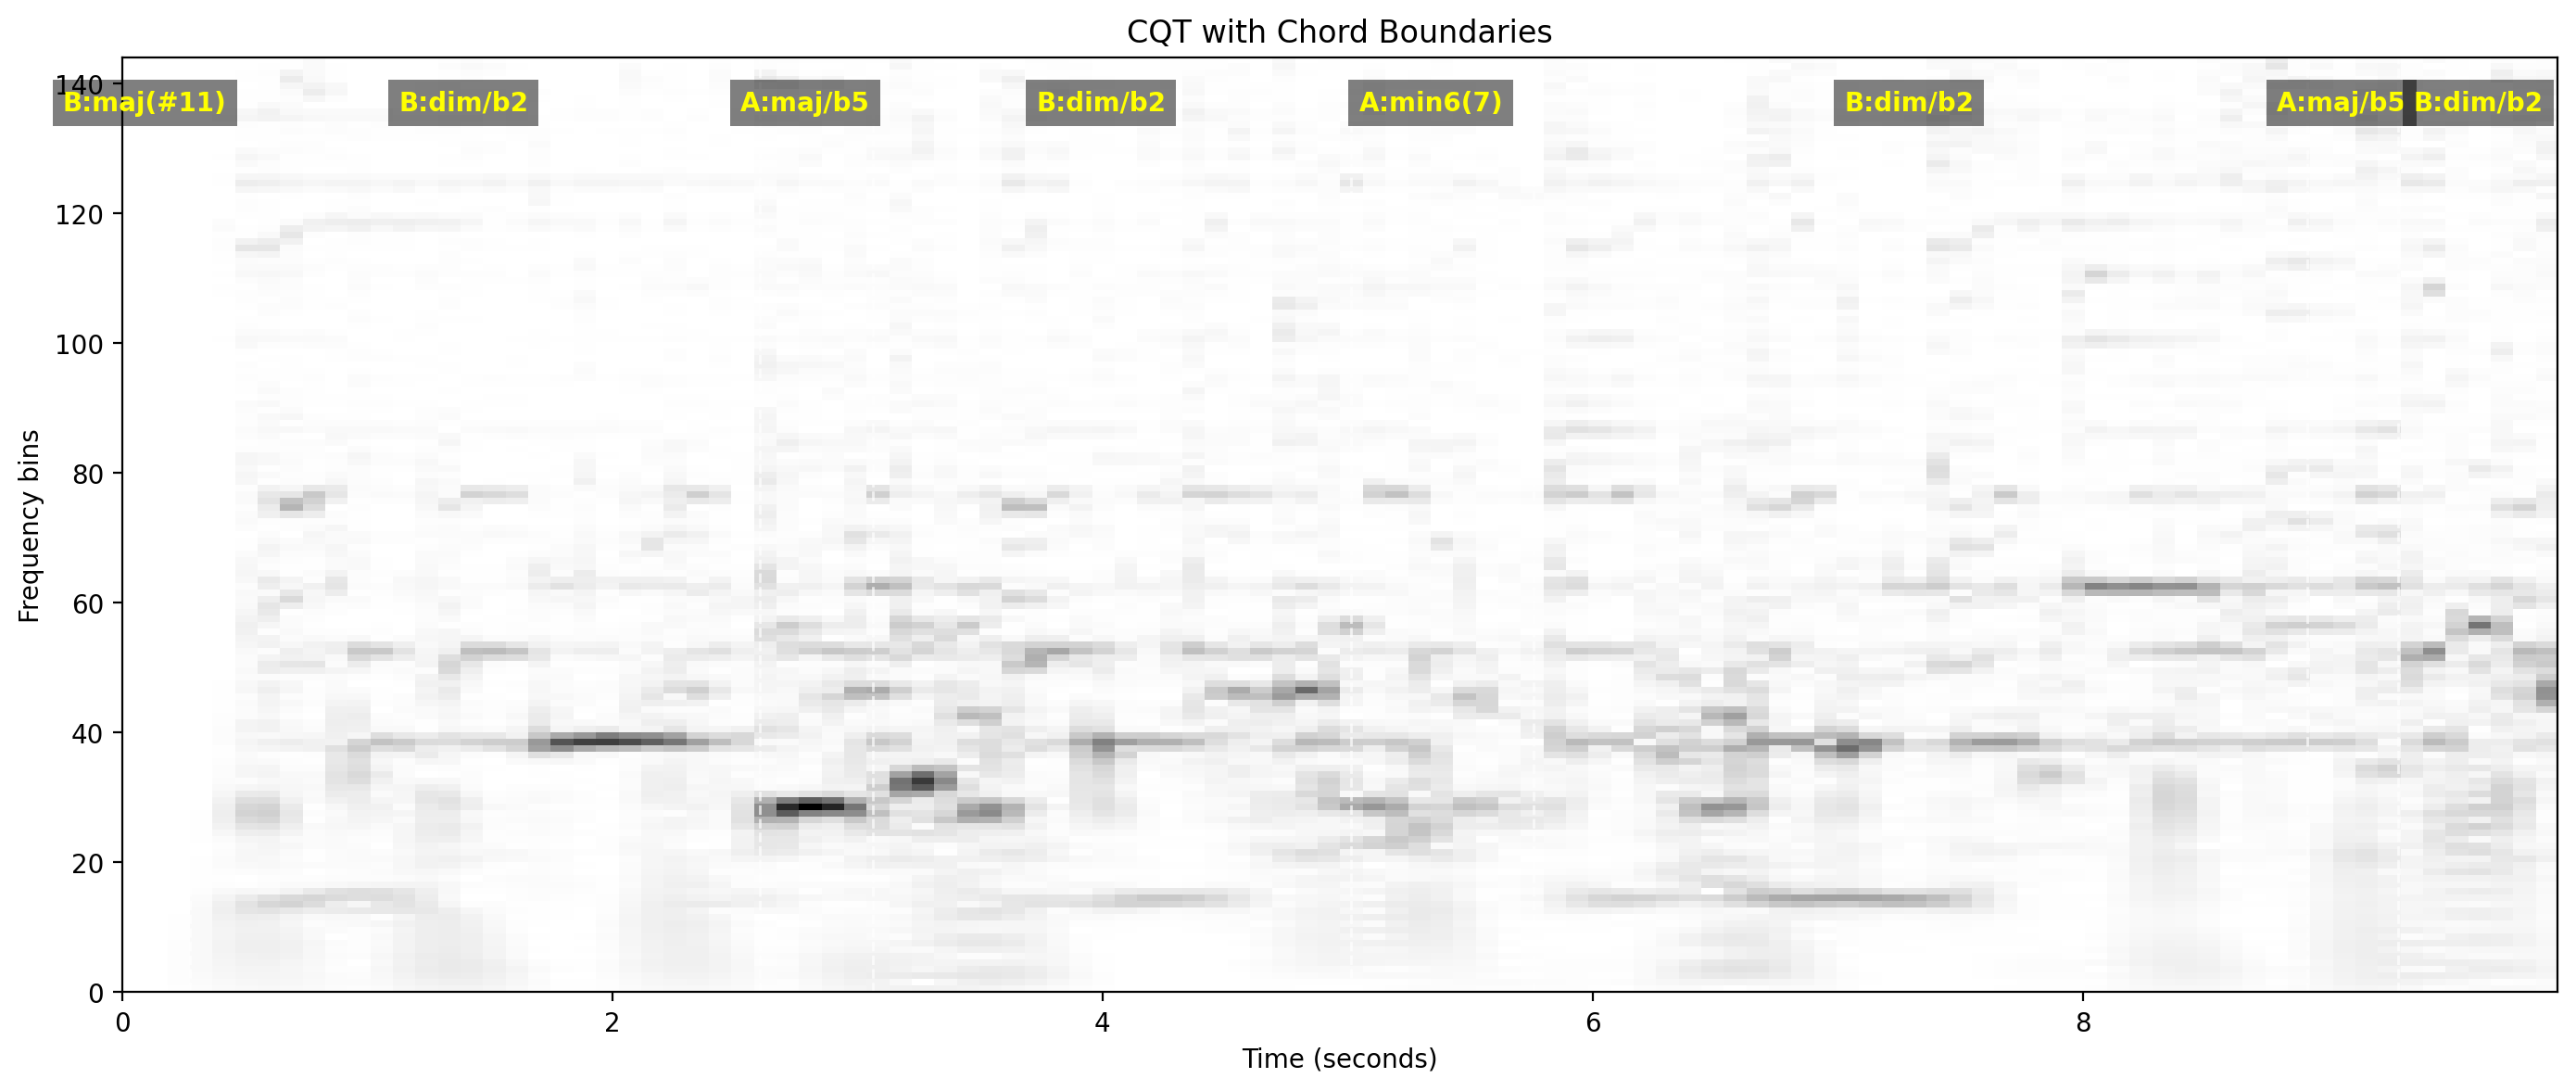

In [18]:
# Visualise CQT with chord labels, experiment with the label key parameter
a.load_and_plot_cqt_with_chords(
    "MIR_Homework_2_Data\\preprocessed_data\\preprocessed_data\\Billboard_TRBGZPI149E312C871_t0000_p-2.pt",
    vocab_file="MIR_Homework_2_Data\\chords_vocab.joblib",
    label_key="complete" # bass, root, complete etc..
)

## Part 2: Training

Using the `ACE` package train both a conformer and conformer decomposed model.

### Tips for training
If you are training on cpu change `train.accelerator` to `'cpu'` otherwise leave as `'cuda'` if you are training on gpu.

The standard conformer model takes ~20 minutes to train 10 epochs on the T4 gpu on colab

If you are using colab you can download your checkpoints to avoid having to retrain the model.

For example:

```python
import shutil
from google.colab import files

# Path to your checkpoints folder
folder_path = "/content/checkpoints"

# Create a zip file
shutil.make_archive("checkpoints_backup", "zip", folder_path)

# Download it
files.download("checkpoints_backup.zip")
```

In [ ]:
from ACE.trainer import main as ace_train_model

# for local
train_data_path = "C:\\UPF\\MIR\\mir-homework-02-CallMeRafaelMP\\MIR_Homework_2_Data\\preprocessed_data\\preprocessed_data"
vocab_path = "MIR_Homework_2_Data\\chords_vocab.joblib"
checkpoint_path = "MIR_Homework_2_Data\\checkpoints"
checkpoint_decomposed_path = "MIR_Homework_2_Data\\checkpoints_decomposed"


# uncomment for colab
# train_data_path = "/content/preprocessed_data"
# vocab_path = "/content/chords_vocab.joblib"
# checkpoint_path = "/content/checkpoints"

### Train conformer

In [20]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ CUDA está disponible!")
    print(f"Dispositivo: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("❌ CUDA no detectada. Usando CPU.")

print(f'CUDA disponible: {torch.cuda.is_available()}'); print(f'Dispositivo: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

✅ CUDA está disponible!
Dispositivo: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA disponible: True
Dispositivo: NVIDIA GeForce RTX 5060 Laptop GPU


In [21]:
import sklearn
print(f"Versión actual: {sklearn.__version__}")

Versión actual: 1.6.1


In [ ]:
ace_train_model(
	model_name="conformer",
	run_name="colab_conformer_01",
	params={
		"train.data_path": train_data_path,
		"train.vocab_path": vocab_path,
		"train.max_epochs": 10,
		"train.accelerator": "cuda",
		"ModelCheckpoint.dirpath": checkpoint_path,
		"ModelCheckpoint.save_last": True # Saves the last model during training.
	}
)

2026-02-16 23:44:26,435 - root - INFO - system_path_file_exists:ACE/trainer.gin
2026-02-16 23:44:26,436 - root - INFO - gin-config opened resource file:c:\UPF\MIR\mir-homework-02-CallMeRafaelMP\.venv\Lib\site-packages\ACE\trainer.gin
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2026-02-16 23:44:26,683 - ACE.dataloader - INFO - Train set: 42 songs, Validation set: 8 songs, Test set: 11 songs


Found 24156 training files and 7260 test files.
Training IDs: ['Isophonics_TRAKIXJ149E332D53F', 'Isophonics_TRCEYZQ149E395A373', 'Isophonics_TRECLAG149E3600A62', 'Isophonics_TRELVER149E34135C0', 'Isophonics_TRETCNL149E39DDF39']... 
Test IDs: ['MARL_TRBFMXE149E3E18222', 'MARL_TRBKNSX149E2E1F89F', 'MARL_TRFVOOM127FA301CFB', 'MARL_TRKINMI127FA68F716', 'MARL_TRMLNPR149E35EF902']... 
Data path: C:\UPF\MIR\mir-homework-02-CallMeRafaelMP\MIR_Homework_2_Data\preprocessed_data\preprocessed_data


c:\UPF\MIR\mir-homework-02-CallMeRafaelMP\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:654: Checkpoint directory C:\UPF\MIR\mir-homework-02-CallMeRafaelMP\MIR_Homework_2_Data\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                 | Type               | Params | Mode 
--------------------------------------------------------------------
0 | positional_encodings | PositionalEncoding | 0      | train
1 | input_projection     | Linear             | 37.1 K | train
2 | conformer            | Conformer          | 6.1 M  | train
3 | output_projection    | Linear             | 6.7 K  | train
4 | train_accuracy       | MulticlassAccuracy | 0      | train
5 | val_accuracy         | MulticlassAccuracy | 0      | train
6 | test_accuracy        | MulticlassAccuracy | 0      | train
--------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total pa

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\UPF\MIR\mir-homework-02-CallMeRafaelMP\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 618/618 [00:18<00:00, 32.54it/s, v_num=csor, train_accuracy=0.902]


2026-02-16 23:49:10,610 - ACE.dataloader - INFO - Train set: 42 songs, Validation set: 8 songs, Test set: 11 songs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 5/5 [00:00<00:00, 28.56it/s]Estimated labels: ['G:maj', 'A:maj', 'F#:min', 'A:maj', 'F#:min', 'B:min']
Reference labels: ['N', 'G:maj6', 'B:min7/5', 'G:maj6', 'A:maj6', 'B:min7']
Scores: {'root': 0.17362592592145562, 'majmin': 0.17362592592145562, 'mirex': 0.2887759007444537, 'sevenths': 0.0, 'thirds': 0.17362592592145562, 'triads': 0.17362592592145562, 'tetrads': 0.0, 'majmin_inv': 0.17362592592145562, 'sevenths_inv': 0.0, 'thirds_inv': 0.17362592592145562, 'triads_inv': 0.17362592592145562, 'tetrads_inv': 0.0, 'tbt': 0.20792851019202288, 'mechanical': 4.677887033022665, 'mechanical_consonance': 5.781807498764936}
Testing DataLoader 0: 100%|██████████| 5/5 [00:02<00:00,  1.84it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric               DataLoader 0
───────────────────────────────────────────────────────────────────────────────────────────────────────

epoch,▁▁▂▂▂▂▃▃▄▄▅▅▅▅▆▆▇▇▇▇█
lr-AdamW,███▇▆▆▅▄▂▁
test_accuracy,▁
test_loss,▁
test_majmin,▁
test_majmin_inv,▁
test_mechanical,▁
test_mechanical_consonance,▁
test_mirex,▁
test_root,▁
+14,...


### Train the decomposed model

In [25]:
ace_train_model(
	model_name="conformer_decomposed",
	run_name="colab_conformer_decomposed_01",
	params={
		"train.data_path": train_data_path,
		"train.vocab_path": vocab_path,
		"train.max_epochs": 10,
		"train.accelerator": "cuda",
		"ModelCheckpoint.dirpath": checkpoint_decomposed_path,
		"ModelCheckpoint.save_last": True
	}
)

NameError: name 'checkpoint_decomposed_path' is not defined

### Compare predictions of the `conformer` and `conformer_decomposed` models on the test set

- Implement `run_inference_on_folder` in `utils.py` and run inference using the trained model checkpoints on the provided `test_audio` folder.
- Analyse the resulting predictions. You may want to use simple code-based statistical methods to aggregate predictions and support your observations.
- Identify and describe the major differences between the predictions of the two models as part of **✏️ Task 2** below.

In [ ]:
# Implement the function run_inference_on_folder in utils.py
checkpoint_conformer = "MIR_Homework_2_Data\\checkpoints\\epoch=7-step=4944.ckpt"
checkpoint_conformer_decomposed = "MIR_Homework_2_Data\\checkpoints_decomposed\\epoch=7-step=4944.ckpt"
u.run_inference_on_folder(
	model_name="conformer",
	audio_folder="MIR_Homework_2_Data\\test_audio\\test_audio",
	checkpoint=checkpoint_conformer, # point to your checkpoint
	vocab_path="MIR_Homework_2_Data\\chords_vocab.joblib",
	output_folder="C:\\UPF\\MIR\\mir-homework-02-CallMeRafaelMP\\inference_outputs_conformer"
)

u.run_inference_on_folder(
	model_name="conformer_decomposed",
	audio_folder="MIR_Homework_2_Data\\test_audio\\test_audio",
	checkpoint=checkpoint_conformer, # point to your checkpoint
	vocab_path="MIR_Homework_2_Data\\chords_vocab.joblib",
	output_folder="C:\\UPF\\MIR\\mir-homework-02-CallMeRafaelMP\\inference_outputs_conformer_decomposed"
)

Iniciando inferencia para 11 archivos...
Procesando: TRBFMXE149E3E18222.mp3...
✅ Loaded model from MIR_Homework_2_Data\checkpoints\epoch=7-step=4944.ckpt and vocab from MIR_Homework_2_Data\chords_vocab.joblib
🔍 Processing 11 chunks of ~20.0s each
Chunk 1/11 (start 0.0s)
Chunk 2/11 (start 20.0s)
Chunk 3/11 (start 40.0s)
Chunk 4/11 (start 60.0s)
Chunk 5/11 (start 80.0s)
Chunk 6/11 (start 100.0s)
Chunk 7/11 (start 120.0s)
Chunk 8/11 (start 140.0s)
Chunk 9/11 (start 160.0s)
Chunk 10/11 (start 180.0s)
Chunk 11/11 (start 200.0s)
💾 Saved C:\UPF\MIR\mir-homework-02-CallMeRafaelMP\inference_outputs_conformer\TRBFMXE149E3E18222_model.lab
Procesando: TRBKNSX149E2E1F89F.mp3...
✅ Loaded model from MIR_Homework_2_Data\checkpoints\epoch=7-step=4944.ckpt and vocab from MIR_Homework_2_Data\chords_vocab.joblib
🔍 Processing 11 chunks of ~20.0s each
Chunk 1/11 (start 0.0s)
Chunk 2/11 (start 20.0s)
Chunk 3/11 (start 40.0s)
Chunk 4/11 (start 60.0s)
Chunk 5/11 (start 80.0s)
Chunk 6/11 (start 100.0s)
Chunk 7/

In [ ]:
# YOUR CODE HERE
with open("inference_outputs_conformer/TRBFMXE149E3E18222.lab", "r") as f:
    print("Muestra de predicción:")
    print("".join(f.readlines()[:5]))

with open("inference_outputs_conformer/TRBFMXE149E3E18222.lab", "r") as f:
    print("Muestra de predicción:")
    print("".join(f.readlines()[:5]))

Muestra de predicción:
0.000000	8.979118	A:min7
8.979118	10.046404	A#:sus2
10.046404	11.067285	A:min7
11.067285	11.577726	A:dim7
11.577726	12.737819	A:min7

Muestra de predicción:
0.000000	8.979118	A:min7
8.979118	10.046404	A#:sus2
10.046404	11.067285	A:min7
11.067285	11.577726	A:dim7
11.577726	12.737819	A:min7



### ✏️ Task 2: Discuss the results of conformer vs conformer_decomposed architectures


Consider the following areas:


- **Discuss** what you see are the differences in the types of predictions the conformer vs the conformer_decomposed model are making.
- Consider the **limitations of the dataset** used to train the models and its impact on the [**mir_eval metrics**](https://mir-eval.readthedocs.io/latest/api/chord.html) and training logs (such as validation loss) you see in weights and biases. Identify, discuss and compare **two** results for each model.


(Note that the `test_accuracy` metric is calculated differently for the conformer and conformer_decomposed model and so are not directly comparable.)

> YOUR RESPONSE HERE

## Part 3: Training with different types of data


Based on your findings from Part 1, explore the effect of training on different subsets of the dataset:


- Select and train on a subsection of the training data (e.g. Isophonics only).
- Train either the `conformer` or `conformer_decomposed` architecture for this experiment.
- Evaluate and discuss the resulting model performance in **✏️ Task 3**. E.g. Consider how the size of the training vocabulary influences performance.


*Note: The ACE module is hardcoded to use Isophonics and Billboard data for training, and MARL data for testing.*

In [ ]:
# You may use the provided function to copy files you want to train on to a new folder
# For example, this copies just the Isophonics and MARL datasets to a new folder
# So you can train on just Isophonics data and test on MARL data:
a.copy_selected_files(
    source_folder="MIR_Homework_2_Data\\preprocessed_data\\preprocessed_data",
    destination_folder="C:\\UPF\\MIR\\mir-homework-02-CallMeRafaelMP\\isophonics_marl_data",
    prefixes=["Isophonics", "MARL"] # MARL is the test dataset
)

Copied 11004 files from MIR_Homework_2_Data\preprocessed_data\preprocessed_data to C:\UPF\MIR\mir-homework-02-CallMeRafaelMP\isophonics_marl_data


In [ ]:
# YOUR CODE HERE

: 

### ✏️ Task 3: Discuss the results of training with a more limited vocabulary

Discuss the effect on [**mir_eval metrics**](https://mir-eval.readthedocs.io/latest/api/chord.html) when training on a more limited dataset. 
- Pick and discuss the results of **two** metrics from the results logged to [weights and biases](https://wandb.ai). Feel free to export any images or figures to include in your response.

> YOUR RESPONSE HERE

## Part 4: Error Analysis

Using the provided checkpoint for the decomposed model `conformer_decomposed_smooth.ckpt`, then `run_inference` on **`TRBKNSX149E2E1F89F.mp3`** of the test data and **one track of your own music**. 

- Pick some of the supplied audio files from the MARL test data. Listen and visualise them using [Sonic Visualiser](https://sonicvisualiser.org/) or any other tool/code you wish.

- Run inference on the files and discuss the predictions vs the ground truth labels and what you hear.

#### Some tips for using Sonic Visualiser:
- You can load the `.lab` prediction file by simply dragging the file into Sonic Visualiser.
- To have the predictions and the ground truth files displaying comfortably together:

	- For the predictions layer: `Plot type = Segmentation`. Then for the ground truth layer, set `Plot Type = Bars`

In [ ]:
from pathlib import Path
from ACE.inference import run_inference

run_inference(
    audio_path="test_audio/TRBKNSX149E2E1F89F.mp3",
    checkpoint=checkpoint_conformer,
    vocab_path="chords_vocab.joblib",
    out_lab=Path("output_lab.lab"),
    chord_min_duration=0.5
)

TypeError: ConformerDecomposedModel.__init__() got an unexpected keyword argument 'hidden_dim'
  In call to configurable 'ConformerDecomposedModel' (<class 'ACE.models.conformer_decomposed.ConformerDecomposedModel'>)

In [ ]:
# Convert the JAMS file of the track you are comparing to a .lab file so you can compare results easily

jams_file = a.get_jams_for_audio(
	audio_path="test_audio/TRBKNSX149E2E1F89F.mp3",
	jams_dir="jams"
)

a.convert_jams_to_lab_file(jams_path=jams_file, lab_path="TRBKNSX149E2E1F89F_labfile.lab")

FileNotFoundError: JAMS file not found for test_audio/TRBKNSX149E2E1F89F.mp3 at jams\TRBKNSX149E2E1F89F.jams

### ✏️ Task 4: Identify and discuss errors

Discuss the results for `test_audio/TRBKNSX149E2E1F89F.mp3` and one track of your choosing (your own music file).

**Consider**
- What are the errors with chord predictions in terms of the chord labels themselves and the timestamp(s) they are predicted at.
- Suggest what might be causing the errors you see. Is it due to the model design/implementation or specific features in the audio that make it hard to predict?

You can include screenshots from Sonic Visualiser in your response. 


> YOUR RESPONSE HERE

## Part 5: Extensions

Now that you have successfully inspected the data, trained conformer and decomposed models, observed the effects of training with different dataset compositions and finally analysed errors, it’s time to explore and implement some possible improvements. You should aim to explore **one** idea, implement it, and then discuss its effects on performance or the types of predictions the model makes — i.e., does it help address any issues identified in the *error analysis* section? If it improves performance, does this come with any drawbacks?

Some possible ideas for exploration
- **Beat-Level Smoothing of Chord Predictions** - smooth the model’s output by averaging or consolidating chord predictions at the beat level using a beat-tracking model.
	- You may use an off-the-shelf beat detection model. E.g [Beat this!](https://github.com/CPJKU/beat_this/tree/main) or librosa or essentia beat detection methods.

- **Experiment with the threshold value**. The `threshold` value parameter for `run_inference` for the conformer_decomposed model controls how confident a chord component (interval) prediction must be to be included in the final chord prediction.
	- Can you tune the threshold value to improve predictions?
	- How does setting the value high or low effect the types of chords predicted?

- **Improve model inference with chunk smoothing**. Currently the inference code for the model predicts chunk after chunk with no overlap. Because of this, at chunk boundaries there can often be repeated or unusual predictions. 
	- You might look into extending the existing inference code to counter the issues that arise from this implementation.
	- Consider overlapping chunks that are being predicted so as to smooth predictions at chunk boundaries.
	- Hint: You might start this by extending the `run_inference` code you have been using. Simply copy the function into a cell here, rename it, and import the relevant dependencies. Then you may implement your changes.

		Example of chunk boundary predictions:

```TSV
	197.656613	198.329466	A:min7
	198.329466	200.000000	A:min
	200.000000	202.761021	F:maj7
```

- **Explore how stem separated music might affect predictions**
   - You might use an off-the-shelf stem separation model, then evaluate predictions. How does this affect predictions?

- **Your own ideas**!

### Note
Don't spend more than one hour implementing and discussing your extension. It is sufficient to test and evaluate your changes on just one or a few different files.

### ✏️ Task 5: Implement and discuss your extension

In [ ]:
# YOUR CODE HERE

: 

> YOUR RESPONSE HERE